In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
from torchvision import datasets, transforms

SEED = 178
np.random.seed(SEED)

ROOT = Path.cwd().parent.parent
TRAIN_DIR = ROOT / "data" / "cifar10" / "train"
TEST_DIR = ROOT / "data" / "cifar10" / "test"
GRAPH_DIR = ROOT / "outputs" / "graphs"

transform = transforms.ToTensor()
train_set = datasets.CIFAR10(root=str(TRAIN_DIR), train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root=str(TEST_DIR), train=False, download=True, transform=transform)

X_train = train_set.data
y_train = np.array(train_set.targets)

X_test = test_set.data
y_test = np.array(test_set.targets)

# Reshape the data to be 2D (n_samples, n_features)
n_samples, n_rows, n_cols, n_channels = X_train.shape
X_train = X_train.reshape(n_samples, -1)

n_samples, n_rows, n_cols, n_channels = X_test.shape
X_test = X_test.reshape(n_samples, -1)

# Split the training data into a training set and a validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=SEED)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)


pca = PCA(n_components=25)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

Training set shape: (37500, 3072)
Validation set shape: (12500, 3072)
Test set shape: (10000, 3072)


In [3]:
# Model A: KNN without PCA and with best K
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Model B: KNN with best PCA and best K
knn_pca = KNeighborsClassifier(n_neighbors=20)
knn_pca.fit(X_train_pca, y_train)

,n_neighbors,20
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [4]:
# Evaluate Model A with final test set
y_pred = knn.predict(X_test)
print("Model A - KNN without PCA:")
print("Accuracy:", accuracy_score(y_test, y_pred))

y_pred_pca = knn_pca.predict(X_test_pca)
print("Model B - KNN with PCA:")
print("Accuracy:", accuracy_score(y_test, y_pred_pca))



Model A - KNN without PCA:
Accuracy: 0.343
Model B - KNN with PCA:
Accuracy: 0.4093


In [6]:
def plot_confusion_matrix(conf_matrix, classes, title='Confusion Matrix'):
    
    plt.figure(figsize=(10, 8))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(GRAPH_DIR / f"{title}.png")

Model A - KNN without PCA:
Confusion Matrix:
Classification Report:
              precision    recall  f1-score   support

    airplane       0.41      0.47      0.44      1000
  automobile       0.64      0.21      0.32      1000
        bird       0.24      0.37      0.29      1000
         cat       0.28      0.24      0.25      1000
        deer       0.25      0.47      0.33      1000
         dog       0.35      0.27      0.31      1000
        frog       0.32      0.35      0.33      1000
       horse       0.53      0.27      0.36      1000
        ship       0.38      0.60      0.47      1000
       truck       0.58      0.18      0.28      1000

    accuracy                           0.34     10000
   macro avg       0.40      0.34      0.34     10000
weighted avg       0.40      0.34      0.34     10000



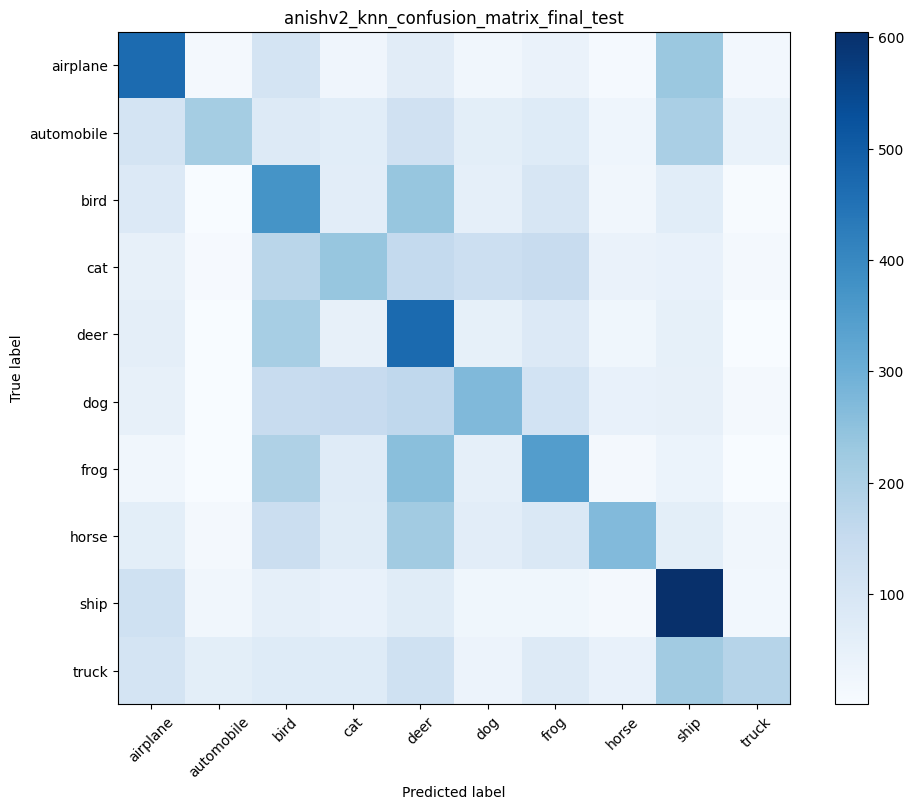

In [9]:
# Model A confusion matrix and classification report
print("Model A - KNN without PCA:")
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_matrix, classes=train_set.classes, title='anishv2_knn_confusion_matrix_final_test')
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=train_set.classes))

Model B - KNN with PCA:
Confusion Matrix:
Classification Report:
              precision    recall  f1-score   support

    airplane       0.45      0.59      0.51      1000
  automobile       0.57      0.38      0.45      1000
        bird       0.28      0.37      0.32      1000
         cat       0.36      0.20      0.25      1000
        deer       0.29      0.43      0.35      1000
         dog       0.47      0.25      0.33      1000
        frog       0.34      0.56      0.42      1000
       horse       0.55      0.33      0.41      1000
        ship       0.48      0.64      0.55      1000
       truck       0.60      0.35      0.44      1000

    accuracy                           0.41     10000
   macro avg       0.44      0.41      0.40     10000
weighted avg       0.44      0.41      0.40     10000



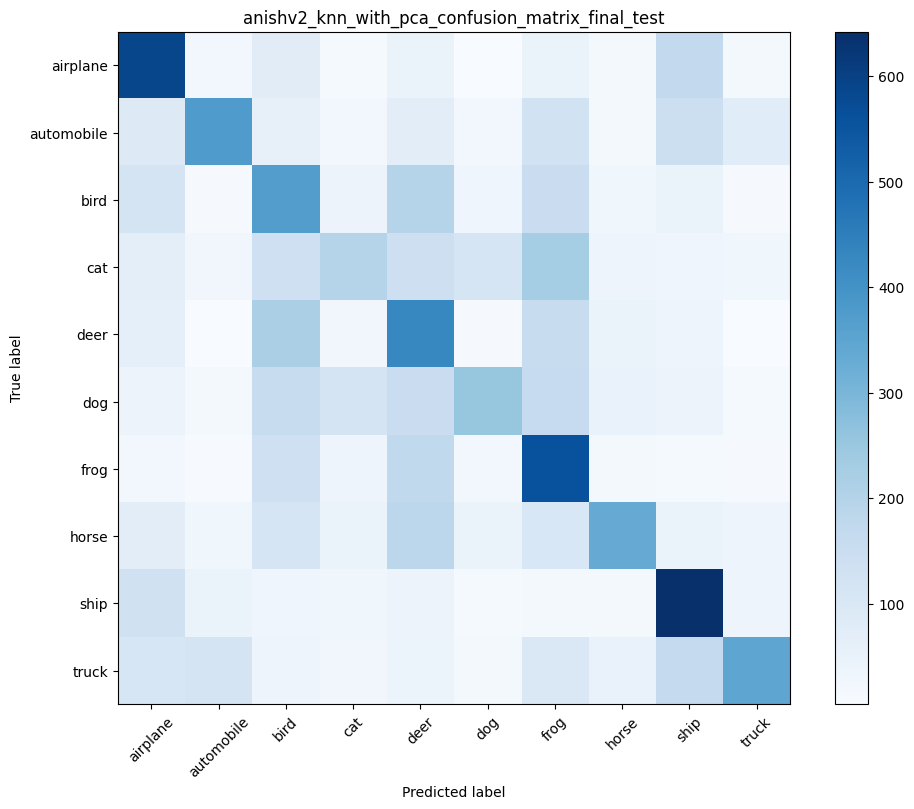

In [8]:
# Model B confusion matrix and classification report
print("Model B - KNN with PCA:")
print("Confusion Matrix:")
conf_matrix_pca = confusion_matrix(y_test, y_pred_pca)
plot_confusion_matrix(conf_matrix_pca, classes=train_set.classes, title='anishv2_knn_with_pca_confusion_matrix_final_test')
print("Classification Report:")
print(classification_report(y_test, y_pred_pca, target_names=train_set.classes))
